# Deep Neural Networks with PyTorch - From MLPs to Real Training

In this notebook we move from simple machine learning models to real neural networks trained on real data, focusing on how deep learning systems learn and generalize.

We build and train neural networks in PyTorch and visualize how they transform data step by step.

---

**🧠 What we will learn**

1. What Feed-Forward Neural Networks (FFNNs) are  
2. How hidden layers and activations build representations  
3. How neural networks are trained using backpropagation  
4. How overfitting and regularization affect learning  
5. How CNNs extract visual features from images  

---

**📦 Datasets**

We use simple datasets to build intuition:
- Iris dataset (tabular classification)
- MNIST dataset (handwritten digit images)

They allow us to visualize both training dynamics and learned representations.

---

**🔥 Core idea**

Neural networks learn by gradually transforming raw inputs into representations where the problem becomes easier to solve.

---

**🧠 Mental model**

Deep learning is:
> learning useful representations layer-by-layer using gradient descent

# 🔥 1. Feed-Forward Neural Networks (FFNN)

A Feed-Forward Neural Network is a neural network where information flows only in one direction:

$
input → hidden\ layers → output
$

Each layer performs:
- linear transformation
- nonlinear activation

This allows the network to gradually learn more complex patterns.

---

**🧱 Example architecture**

A small neural network may look like:

$
4 → 8 → 8 → 3
$

Meaning:
- 4 input features
- 2 hidden layers with 8 neurons
- 3 output classes

---

**🧠 Why hidden layers matter**

Without hidden layers, the model behaves like logistic regression and can only learn linear boundaries.

Hidden layers allow the network to:
- combine features
- build internal representations
- learn nonlinear patterns

---

**⚡ Key idea**

Each layer transforms the data into a representation that becomes easier for the next layer to use.

# 🌸 2. Loading a Real Dataset (Iris)

The classic Iris dataset is one of the most famous datasets in machine learning.

It contains measurements of iris flowers:
- sepal length
- sepal width
- petal length
- petal width

The task is to classify flowers into 3 species:
- Setosa
- Versicolor
- Virginica

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

(150, 4)
(150,)


## 🔁 Train / Test Split

We split the dataset into:
- training data (used for learning)
- test data (used for evaluation)

We also normalize features because neural networks train better on standardized inputs.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(y_train.shape)

torch.Size([120, 4])
torch.Size([120])


# 🔥 3. Building Our First Real Neural Network

We now create a small MLP:

$
4 → 16 → 16 → 3
$

Architecture:
- input layer: 4 features
- hidden layers: learn internal representations
- output layer: predicts flower class

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class IrisMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 3)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

model = IrisMLP()

print(model)

IrisMLP(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
)


## 🧠 Understanding the architecture

**Input layer**
Receives 4 flower measurements.

**Hidden layers**
Learn useful internal patterns using:
- weights
- activations
- feature combinations

**ReLU activation**
Introduces nonlinearity:

$
ReLU(x) = max(0, x)
$

Without activations, the whole network would collapse into a single linear transformation.

**Output layer**
Produces 3 logits (one for each flower class).

# 🔁 4. Training the Neural Network

Now we train the model using:

- forward pass
- loss computation
- backpropagation
- gradient descent

We will also visualize how learning evolves during training.

In [4]:
model = IrisMLP()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 🧠 Why CrossEntropyLoss?

Our task has 3 classes:

- Setosa
- Versicolor
- Virginica

Cross entropy compares:
- predicted class probabilities
- true labels

and penalizes incorrect predictions.

In [5]:
epochs = 200

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    # forward pass
    logits = model(X_train)

    # compute loss
    loss = loss_fn(logits, y_train)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # accuracy
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y_train).float().mean()

    train_losses.append(loss.item())
    train_accuracies.append(acc.item())

    if epoch % 20 == 0:
        print(
            f"epoch={epoch:3d} | "
            f"loss={loss.item():.4f} | "
            f"acc={acc.item():.4f}"
        )

epoch=  0 | loss=1.1263 | acc=0.2500
epoch= 20 | loss=0.4005 | acc=0.8167
epoch= 40 | loss=0.1378 | acc=0.9583
epoch= 60 | loss=0.0586 | acc=0.9667
epoch= 80 | loss=0.0467 | acc=0.9833
epoch=100 | loss=0.0434 | acc=0.9833
epoch=120 | loss=0.0419 | acc=0.9833
epoch=140 | loss=0.0403 | acc=0.9833
epoch=160 | loss=0.0382 | acc=0.9833
epoch=180 | loss=0.0352 | acc=0.9833


# 📉 5. Loss Curve Visualization

The loss curve shows:
- how fast the network learns
- whether training is stable
- whether optimization converges

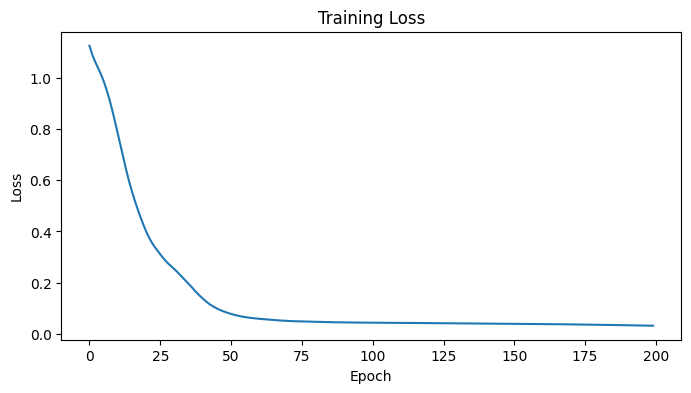

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

# 📈 6. Accuracy Curve Visualization

Accuracy shows how many predictions are correct.

As training progresses:
- loss should decrease
- accuracy should increase

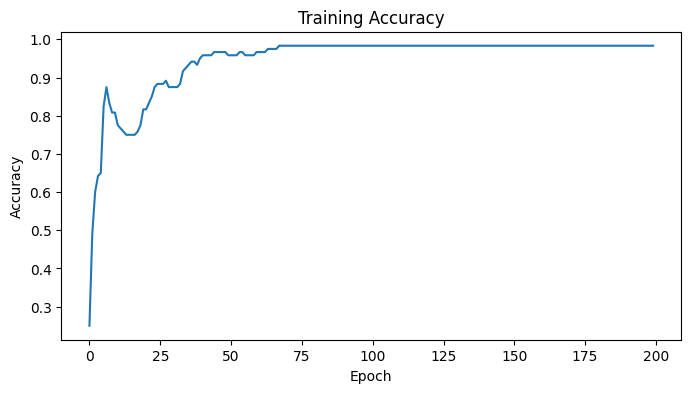

In [7]:
plt.figure(figsize=(8,4))

plt.plot(train_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.show()

# 🧪 7. Model Evaluation

Now we evaluate the model on unseen test data.

In [8]:
with torch.no_grad():

    test_logits = model(X_test)

    test_preds = torch.argmax(test_logits, dim=1)

    test_acc = (test_preds == y_test).float().mean()

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 1.0000


# 🎨 8. Decision Boundary Visualization

Neural networks learn by transforming input space into regions associated with different classes.

To visualize this, we reduce the problem to 2 features:
- petal length
- petal width

This lets us plot the learned decision regions.

In [9]:
# use only 2 features for visualization
X_vis = iris.data[:, 2:4]

y_vis = iris.target

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_vis,
    test_size=0.2,
    random_state=42
)

scaler_vis = StandardScaler()

X_train_vis = scaler_vis.fit_transform(X_train_vis)
X_test_vis = scaler_vis.transform(X_test_vis)

X_train_vis = torch.tensor(X_train_vis, dtype=torch.float32)
y_train_vis = torch.tensor(y_train_vis, dtype=torch.long)

In [10]:
class BoundaryMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 3)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

boundary_model = BoundaryMLP()

optimizer = torch.optim.Adam(
    boundary_model.parameters(),
    lr=0.01
)

loss_fn = nn.CrossEntropyLoss()

In [11]:
for epoch in range(300):

    logits = boundary_model(X_train_vis)

    loss = loss_fn(logits, y_train_vis)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

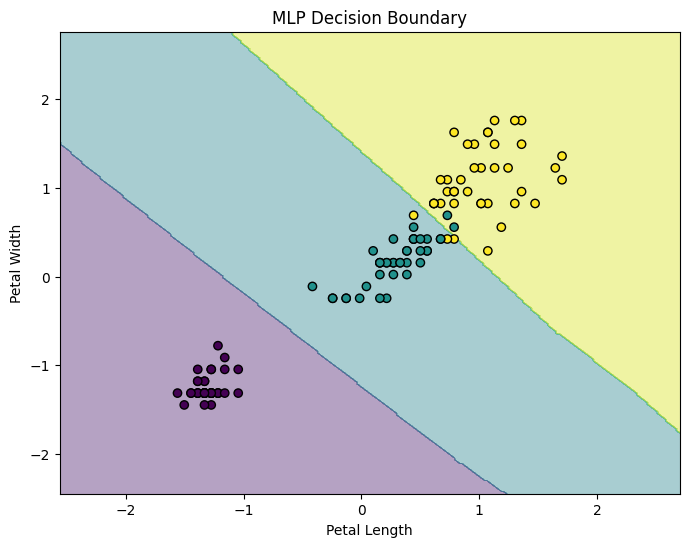

In [12]:
import numpy as np

x_min, x_max = X_train_vis[:,0].min()-1, X_train_vis[:,0].max()+1
y_min, y_max = X_train_vis[:,1].min()-1, X_train_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.tensor(grid, dtype=torch.float32)

with torch.no_grad():

    logits = boundary_model(grid_tensor)

    preds = torch.argmax(logits, dim=1)

Z = preds.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X_train_vis[:,0],
    X_train_vis[:,1],
    c=y_train_vis,
    edgecolor="k"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.title("MLP Decision Boundary")

plt.show()

## 🧠 What this visualization shows

The colored regions represent:
- what class the network predicts
- how the input space is partitioned

The neural network learned nonlinear boundaries by:
- transforming features in hidden layers
- combining multiple learned representations

This is the core idea behind deep learning.

# 📦 9. Dataset and DataLoader

So far we passed the entire dataset directly into the model.

In real deep learning workflows, data is usually processed in small batches using:

- `Dataset` → stores and serves samples
- `DataLoader` → creates iterable mini-batches

This makes training:
- more memory efficient
- faster
- easier to shuffle and preprocess

## ⚙️ TensorDataset

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

Each iteration returns a mini-batch:

$
(X_{batch}, y_{batch})
$

instead of the full dataset at once.

Mini-batch training is the standard approach in deep learning.

## 🔁 Updated training loop

In [14]:
epochs = 200

train_losses = []

for epoch in range(epochs):

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        logits = model(batch_X)

        loss = loss_fn(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss)

    if epoch % 20 == 0:
        print(f"epoch={epoch}, loss={epoch_loss:.4f}")

epoch=0, loss=0.2397
epoch=20, loss=0.2353
epoch=40, loss=0.2742
epoch=60, loss=0.2372
epoch=80, loss=0.2380
epoch=100, loss=0.2516
epoch=120, loss=0.3218
epoch=140, loss=0.2359
epoch=160, loss=0.2357
epoch=180, loss=0.2424


`Dataset` and `DataLoader` separate:
- data handling
- model training

This is the standard structure used in nearly all PyTorch projects.

# ⚡ 10. Activation Functions (ReLU, Tanh, Sigmoid, GELU)

Activation functions introduce non-linearity into neural networks.

Without them:
> a deep network would behave like a single linear model

**🧠 Why activations matter**

Linear layers alone can only learn linear relationships.

Activation functions allow neural networks to:
- bend decision boundaries
- learn complex patterns
- build hierarchical representations

## 📊 Visualization code

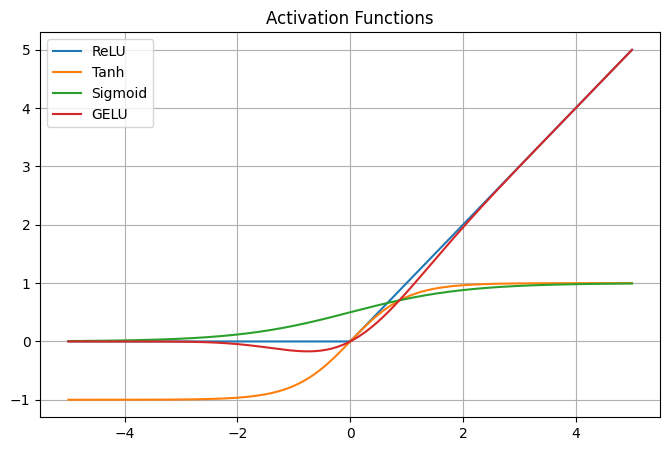

In [15]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 200)

relu = torch.relu(x)
tanh = torch.tanh(x)
sigmoid = torch.sigmoid(x)
gelu = x * 0.5 * (1 + torch.tanh(torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * x**3)))

plt.figure(figsize=(8,5))

plt.plot(x.numpy(), relu.numpy(), label="ReLU")
plt.plot(x.numpy(), tanh.numpy(), label="Tanh")
plt.plot(x.numpy(), sigmoid.numpy(), label="Sigmoid")
plt.plot(x.numpy(), gelu.numpy(), label="GELU")

plt.legend()
plt.title("Activation Functions")
plt.grid(True)

plt.show()

**🧠 Intuition**

**ReLU**
- keeps positive values
- kills negative values
- simple and efficient
- most widely used

**Tanh**
- outputs between -1 and 1
- centered around zero
- smoother but saturates

**Sigmoid**
- outputs 0 to 1
- used for probabilities
- saturates easily

**GELU**
- smooth version of ReLU
- used in transformers
- modern default in large models

# 🚨 11. Overfitting & Generalization in Neural Networks

A neural network is not just learning patterns in data — it is also trying to generalize to unseen data.

This leads to two important concepts:

- **Underfitting** → model is too simple
- **Overfitting** → model memorizes training data instead of learning patterns

## 📦 Dataset (we make problem slightly harder)

We use a noisy non-linear dataset so overfitting becomes visible.

In [16]:
import torch

torch.manual_seed(0)

X = torch.randn(300, 2)

y = ((X[:, 0]**2 + X[:, 1]**2) < 1).float().unsqueeze(1)

# add noise → makes task harder
noise = 0.2 * torch.randn_like(y)
y = (y + noise > 0.5).float()

## 🧠 Train / Test split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 🧠 Two models: simple vs complex

We compare:

1. Small model → generalizes better

2. Large model → tends to overfit

---

### ⚙️ Small model

In [18]:
import torch.nn as nn
import torch.nn.functional as F

class SmallMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

### ⚙️ Large model

In [19]:
class LargeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

### 🔁 Training loop (shared)

In [20]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=200):

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    loss_fn = nn.BCEWithLogitsLoss()

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        # training
        logits = model(X_train)
        train_loss = loss_fn(logits, y_train)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # evaluation
        with torch.no_grad():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

    return train_losses, test_losses

### 🔥 Train both models

In [21]:
small = SmallMLP()
large = LargeMLP()

small_train, small_test = train_model(small, X_train, y_train, X_test, y_test)
large_train, large_test = train_model(large, X_train, y_train, X_test, y_test)

## 📉 Loss curves visualization

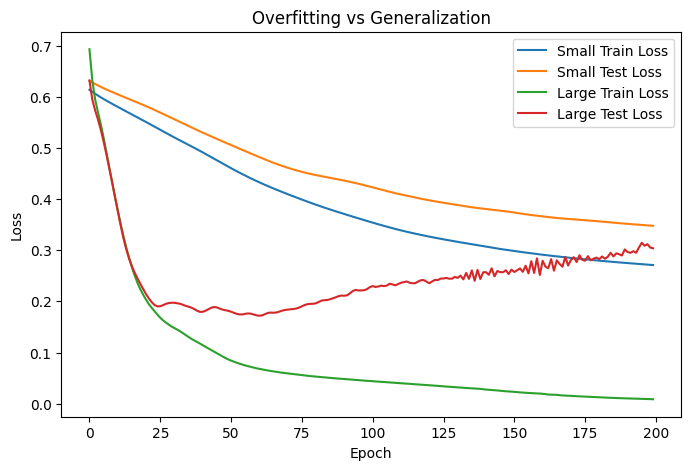

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(small_train, label="Small Train Loss")
plt.plot(small_test, label="Small Test Loss")

plt.plot(large_train, label="Large Train Loss")
plt.plot(large_test, label="Large Test Loss")

plt.legend()
plt.title("Overfitting vs Generalization")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

Overfitting happens when a model learns training data too well, including noise, instead of learning general patterns.

Generalization is the ability to perform well on unseen data.

# 🚀 Regularization in Neural Networks

When neural networks become too powerful, they tend to overfit.

Regularization techniques help prevent this by forcing the model to learn more robust patterns.

## 🧠 Core idea

Regularization = adding constraints to learning so the model generalizes better.

## 🎯 Dropout

Dropout randomly disables neurons during training.

This forces the network to:
- not rely on a single neuron
- learn redundant representations
- become more robust

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DropoutMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        return self.fc3(x)

**Intuition**

Dropout makes training look like:

> every forward pass uses a slightly different network

This prevents co-adaptation of neurons.

## ⚖️ Weight Decay (L2 regularization)

Weight decay discourages large weights by adding a penalty during training.

This makes the model:
- smoother
- less sensitive to noise
- more generalizable

In [24]:
model = DropoutMLP()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=1e-3
)

**🧠 Intuition**

Weight decay pushes weights toward zero.

Smaller weights → simpler model → better generalization.

## 🔥 Batch Normalization

BatchNorm normalizes activations inside the network.

This stabilizes training and speeds up convergence.

In [25]:
class BNMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(2, 64)
        self.bn1 = nn.BatchNorm1d(64)

        self.fc2 = nn.Linear(64, 64)
        self.bn2 = nn.BatchNorm1d(64)

        self.fc3 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        return self.fc3(x)

**🧠 Intuition**

BatchNorm:
- stabilizes input distributions inside the network
- reduces internal “shifts” during training
- allows higher learning rates

It acts like:
> “keeping the network in a stable training environment”

## 📊 Comparison


| Model          | Regularization     |
| -------------- | ------------------ |
| Plain MLP      | none               |
| + Dropout      | randomness         |
| + Weight Decay | smaller weights    |
| + BatchNorm    | stable activations |

In [26]:
dropout = DropoutMLP()
bnmlp = BNMLP()
large = LargeMLP()

dropout_train, dropout_test = train_model(dropout, X_train, y_train, X_test, y_test)
bnmlp_train, bnmlp_test = train_model(bnmlp, X_train, y_train, X_test, y_test)
large_train, large_test = train_model(large, X_train, y_train, X_test, y_test)

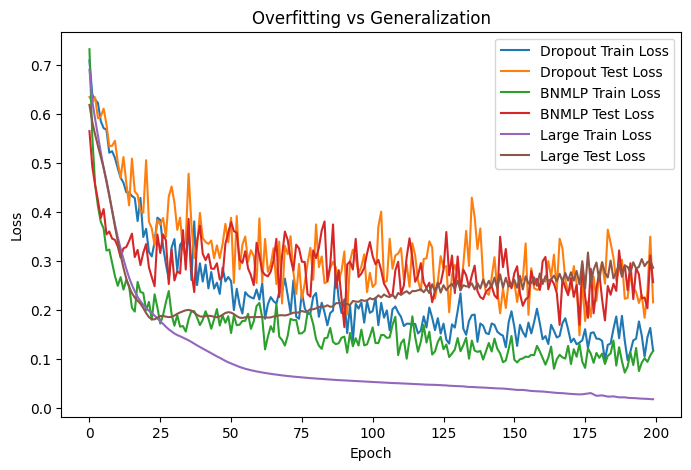

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(dropout_train, label="Dropout Train Loss")
plt.plot(dropout_test, label="Dropout Test Loss")

plt.plot(bnmlp_train, label="BNMLP Train Loss")
plt.plot(bnmlp_test, label="BNMLP Test Loss")

plt.plot(large_train, label="Large Train Loss")
plt.plot(large_test, label="Large Test Loss")

plt.legend()
plt.title("Overfitting vs Generalization")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

# ⚠️ Vanishing Gradients

Vanishing gradients happen when gradients become extremely small during backpropagation in deep neural networks.

As gradients flow backward through many layers, they shrink exponentially, making early layers learn very slowly or not at all.

**🧠 Intuition**

During training:
> each layer passes a learning signal backward

In deep networks, this signal can fade:

input → layer → layer → layer → output  
⬇️        ⬇️       ⬇️  
very small → smaller → almost zero  

Result:
- early layers stop learning
- training becomes inefficient

## ⚙️ Why it happens

Vanishing gradients occur because backpropagation multiplies many small derivatives:

$
\prod \frac{dL}{dx}
$

If these values are < 1 (common with sigmoid/tanh), the product shrinks toward zero.

## 🔥 How it is solved

Modern neural networks avoid vanishing gradients using:

- ReLU / GELU activations  
- Batch Normalization  
- Residual connections (ResNet idea)  
- Better optimizers (Adam)  

# ⚠️ Weight Initialization Problem

Before training even starts, neural networks can fail if weights are not initialized properly.

**🧠 Intuition**

If weights are:
- too small → signals vanish
- too large → signals explode

Both cases make training unstable.

## ⚙️ What goes wrong

Bad initialization leads to:

- vanishing activations (all zeros)
- exploding activations (huge values)
- unstable gradients during backpropagation

## 🔥 Modern solutions

We initialize weights carefully to keep signal stable:

- Xavier / Glorot initialization (for tanh/sigmoid)
- He initialization (for ReLU networks)

Goal:
> keep variance of activations roughly constant across layers

**🧠 Key insight**

Good initialization ensures:
> signals neither vanish nor explode as they move through the network

# 🚀 Convolutional Neural Networks (CNNs)

CNNs are the first neural network architecture designed specifically for image data.

They are the foundation of modern computer vision systems (face recognition, self-driving cars, medical imaging, etc.).

**🧠 Why CNNs?**

Fully connected networks (MLPs) have a problem:

- they treat every pixel independently
- they ignore spatial structure
- they become too large for images

CNNs solve this by:
> learning local patterns like edges, textures, and shapes

## 👁️ Core idea

Instead of connecting every neuron to every pixel:

CNNs use small filters (kernels) that slide across the image.

This allows the network to detect:
- edges
- corners
- textures
- shapes

## ⚙️ Convolution

A convolution applies a small filter over the image:

$
output = image * filter
$

The filter learns to detect specific patterns.

**🧠 Intuition**

Think of a filter as a small "pattern detector":

- one filter detects edges
- another detects curves
- another detects textures

As layers go deeper:
> simple patterns → complex objects

## 🧱 CNN components

A typical CNN has:

1. Convolution layer → extracts features  
2. Activation (ReLU) → adds non-linearity  
3. Pooling → reduces spatial size  
4. Fully connected layer → final prediction  

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## 🔁 Data flow

Image → Conv → ReLU → Pool → Conv → ReLU → Pool → Dense → Output

Each stage:
- reduces size
- increases abstraction
- increases semantic meaning

## 📉 Pooling

Pooling reduces spatial resolution while keeping important information.

It helps:
- reduce computation
- make model robust to small shifts in images

# 🚀 CNN on MNIST - Full Training & Visualization

In this section we train a Convolutional Neural Network on the MNIST dataset.

MNIST contains handwritten digits (0–9), and is a classic benchmark for computer vision.

## 🧠 Why MNIST?

MNIST is ideal because:
- small dataset (fast training)
- simple grayscale images (28×28)
- easy to visualize results
- perfect for understanding CNN behavior

## 📦 Load dataset

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./downloads",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./downloads",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

## 👁️ Visualize sample images

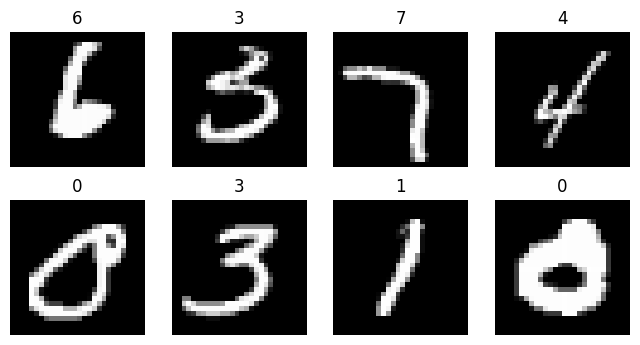

In [9]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(8,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")

plt.show()

## 🧠 CNN Model

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class MNIST_CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

## ⚙️ Training setup

In [11]:
model = MNIST_CNN()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 🔁 Training loop

In [12]:
%%time
train_losses = []

epochs = 5  # MNIST trains fast

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        logits = model(images)

        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_losses.append(total_loss)

    print(f"Epoch {epoch} | Loss: {total_loss:.4f}")

Epoch 0 | Loss: 165.8454
Epoch 1 | Loss: 48.1640
Epoch 2 | Loss: 34.3332
Epoch 3 | Loss: 24.5574
Epoch 4 | Loss: 18.4693
CPU times: user 3min 30s, sys: 5min 25s, total: 8min 56s
Wall time: 1min 25s


## 📉 Loss curve 

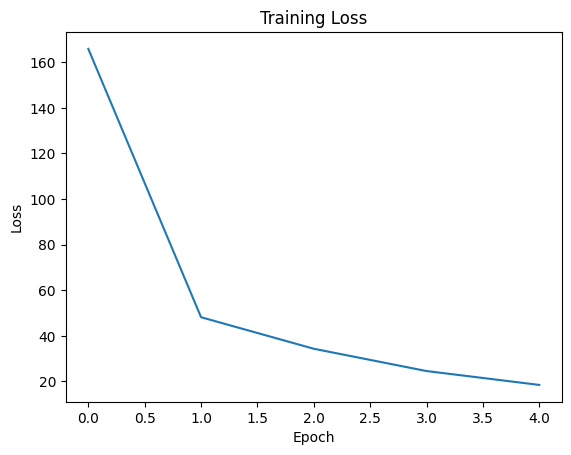

In [13]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 🧪 Test accuracy

In [14]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.9901


## 🔍 Visualize predictions

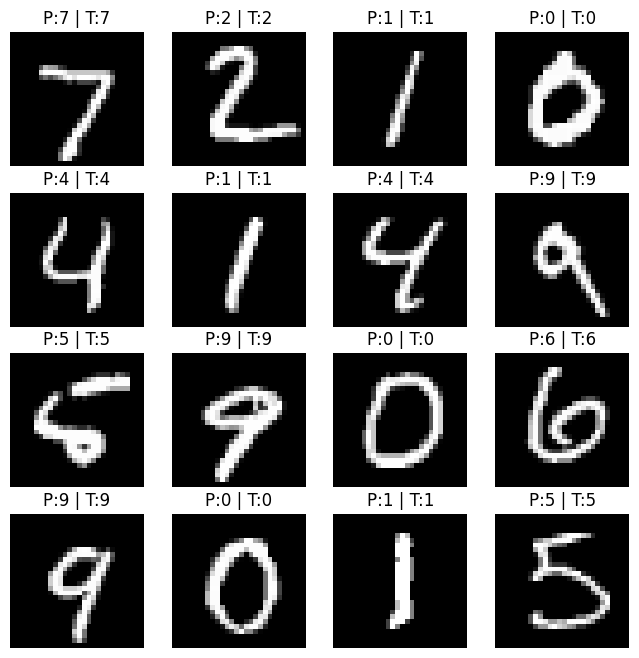

In [17]:
images, labels = next(iter(test_loader))

outputs = model(images)
preds = torch.argmax(outputs, dim=1)

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(images[i][0], cmap="gray")

    plt.title(f"P:{preds[i].item()} | T:{labels[i].item()}")

    plt.axis("off")

plt.show()

## 🧠 What the CNN learned

1. Early layers detect edges and strokes  
2. Middle layers combine shapes  
3. Deep layers recognize digit structure  

Finally:
> it maps pixel patterns → digit labels

CNNs do not “see” digits like humans.

They learn hierarchical feature detectors:
- edges → curves → shapes → digits

A CNN learns to recognize images by stacking filters that gradually transform pixels into meaningful patterns.

# 🚀 Visualizing CNN Filters & Feature Maps

CNNs are often called a “black box”, but we can actually inspect what they learn.

In this section we will visualize:
- learned convolution filters (what the model detects)
- feature maps (what the model “sees” at each layer)

## 🧠 Why this is important

Instead of treating CNNs as black boxes, we can:

- see edge detectors in early layers
- understand abstraction in deeper layers
- build intuition about representation learning

In [18]:
model.eval()

MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## 🔥 Visualizing convolution filters

Each filter in a convolution layer is a small pattern detector.

Before training:
- random noise

After training:
- edge detectors, stroke detectors, texture detectors

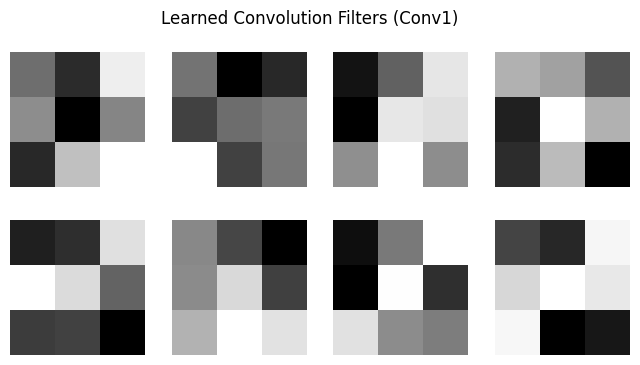

In [19]:
import matplotlib.pyplot as plt

filters = model.conv1.weight.data.clone()

num_filters = filters.shape[0]

plt.figure(figsize=(8,4))

for i in range(min(num_filters, 8)):

    plt.subplot(2, 4, i+1)

    f = filters[i][0]  # first channel

    plt.imshow(f, cmap="gray")

    plt.axis("off")

plt.suptitle("Learned Convolution Filters (Conv1)")
plt.show()

### 🧠 Interpretation

Early filters typically look like:
- edge detectors
- diagonal strokes
- simple gradients

This is the network learning basic visual primitives.

## 🔍 Feature Maps (Activations)

Feature maps show:

> what a layer "sees" when an image is passed through it

In [20]:
# Hook-based extraction
activations = {}

def hook_fn(module, input, output):
    activations["conv1"] = output

model.conv1.register_forward_hook(hook_fn)

In [21]:
# Run a sample image
images, labels = next(iter(test_loader))

sample = images[0].unsqueeze(0)

with torch.no_grad():
    _ = model(sample)

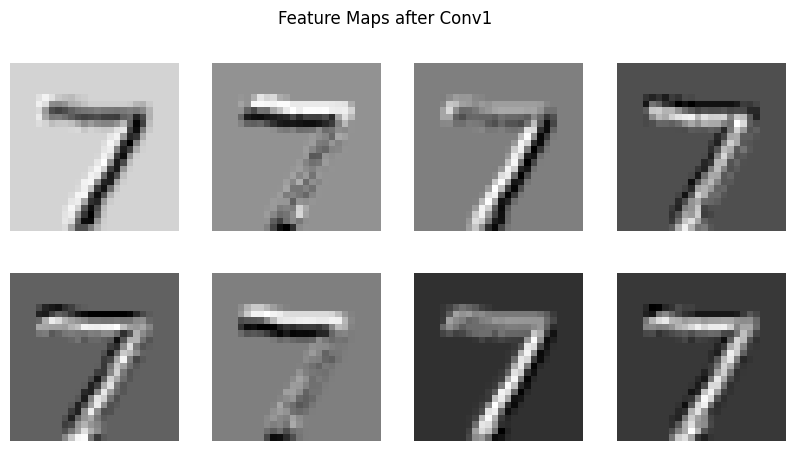

In [22]:
# Visualize feature maps
act = activations["conv1"].squeeze(0)

num_maps = act.shape[0]

plt.figure(figsize=(10,5))

for i in range(min(num_maps, 8)):

    plt.subplot(2,4,i+1)

    plt.imshow(act[i].cpu(), cmap="gray")

    plt.axis("off")

plt.suptitle("Feature Maps after Conv1")
plt.show()

### 🧠 Interpretation

Each feature map represents:

- one learned pattern detector
- activation strength over spatial locations

Bright areas = pattern detected  
Dark areas = pattern not detected

CNNs do not process images as whole objects.

They:
- detect local patterns
- build hierarchical representations
- combine features into abstract concepts